This case requires trainees to develop a model for predicting fraudulent transactions for a
financial company and use insights from the model to develop an actionable plan. Data for the
case is available in CSV format having 6362620 rows and 10 columns.


can use whatever method they wish to develop their machine learning model.
Following usual model development procedures, the model would be estimated on the
calibration data and tested on the validation data. This case requires both statistical analysis and
creativity/judgment. We recommend you spend time on both fine-tuning and interpreting the
results of your machine learning model.

1.Data cleaning including missing values, outliers and multi-collinearity.

2. Describe your fraud detection model in elaboration.

3. How did you select variables to be included in the model?

4. Demonstrate the performance of the model by using best set of tools.

5. What are the key factors that predict fraudulent customer?

6. Do these factors make sense? If yes, How? If not, How not?

7. What kind of prevention should be adopted while company update its infrastructure?

8. Assuming these actions have been implemented, how would you determine if they work?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/Fraud.csv')

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56203 entries, 0 to 56202
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            56203 non-null  int64  
 1   type            56203 non-null  object 
 2   amount          56202 non-null  float64
 3   nameOrig        56202 non-null  object 
 4   oldbalanceOrg   56202 non-null  float64
 5   newbalanceOrig  56202 non-null  float64
 6   nameDest        56202 non-null  object 
 7   oldbalanceDest  56202 non-null  float64
 8   newbalanceDest  56202 non-null  float64
 9   isFraud         56202 non-null  float64
 10  isFlaggedFraud  56202 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 4.7+ MB


In [37]:
df.isnull().sum()

,0
step,0
amount,1
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1
isFlaggedFraud,1


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,56203.000000,5.620200e+04,5.620200e+04,5.620200e+04,5.620200e+04,5.620200e+04,56202.000000,56202.0
mean,7.624451,1.598924e+05,7.322726e+05,7.464767e+05,8.391746e+05,1.169835e+06,0.001779,0.0
std,1.999414,3.293750e+05,2.184696e+06,2.222611e+06,2.407619e+06,2.893515e+06,0.042145,0.0
min,1.000000,6.300000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,8.000000,8.135660e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,8.000000,3.623700e+04,1.788471e+04,0.000000e+00,5.114860e+03,2.167320e+03,0.000000,0.0
75%,9.000000,1.918409e+05,1.401448e+05,1.534157e+05,4.722510e+05,8.965790e+05,0.000000,0.0
max,9.000000,1.000000e+07,2.854724e+07,2.861740e+07,3.017978e+07,3.197699e+07,1.000000,0.0


In [7]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
56198,False
56199,False
56200,False
56201,False


In [8]:
df['type'].value_counts()

,count
type,
PAYMENT,24242
CASH_OUT,15672
CASH_IN,10321
TRANSFER,5267
DEBIT,700
PAYMEN,1


In [9]:
df['type'].mode()

,type
0,PAYMENT


In [40]:
numerical_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
df_no_outliers = df.copy()

for col in numerical_cols:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_no_outliers = df_no_outliers[(df_no_outliers[col]>=lower_bound)&(df_no_outliers[col]<=upper_bound)]

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after outlier removal: {df_no_outliers.shape}")
display(df_no_outliers.head())

Original DataFrame shape: (56203, 16)
DataFrame shape after outlier removal: (25032, 16)


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMEN,type_PAYMENT,type_TRANSFER
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,False,False,False,False,True,False
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,False,False,False,False,False,True
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,False,True,False,False,False,False
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,False,False,False,False,True,False
5,1,7817.71,C90045638,53860.0,46042.29,M573487274,0.0,0.0,0.0,0.0,False,False,False,False,True,False


<Axes: >

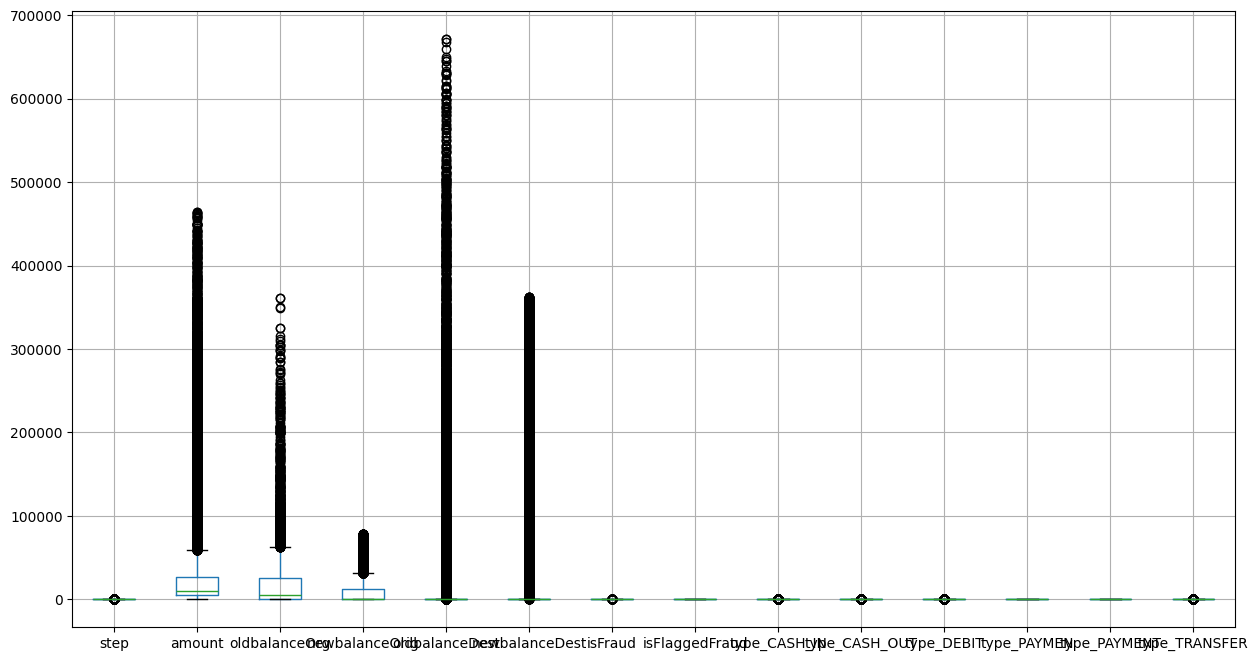

In [53]:
df_no_outliers.boxplot(figsize=(15,8))


In [42]:
for col in numerical_cols:
  Q1=df_no_outliers[col].quantile(0.25)
  Q3=df_no_outliers[col].quantile(0.75)
  IQR= Q3-Q1
  print(col,((df_no_outliers[col]<Q1-1.5*IQR)|(df_no_outliers[col]>Q3+1.5*IQR)).sum())

amount 4014
oldbalanceOrg 1667
newbalanceOrig 3239
oldbalanceDest 5283
newbalanceDest 5195


In [61]:
amount_cols=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

df_processed=df.copy()
for col in amount_cols:
  Q1=df_processed[col].quantile(0.25)
  Q3=df_processed[col].quantile(0.75)
  IQR=Q3-Q1

  lower=Q1-1.5*IQR
  upper=Q3+1.5*IQR

  df_processed[col]=df_processed[col].clip(lower,upper)

In [45]:
for col in amount_cols:
  df_processed[col]=np.log1p(df_processed[col])

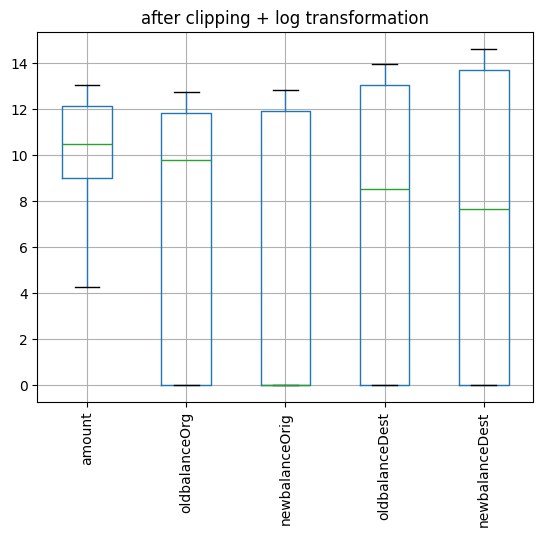

In [59]:
df_processed[amount_cols].boxplot(showfliers=False)
plt.title('after clipping + log transformation')
plt.xticks(rotation=90)
plt.show()

In [54]:
for col in amount_cols:
  lower=df[col].quantile(0.01)
  upper=df[col].quantile(0.99)
  df[col]=df[col].clip(lower,upper)



<Axes: >

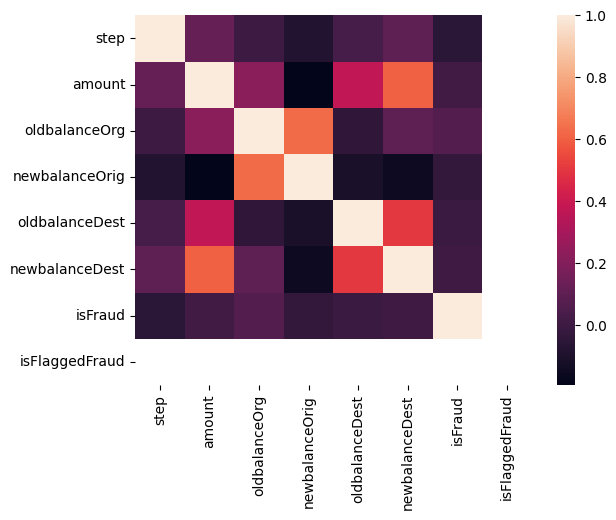

In [29]:
numerical_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
sns.heatmap(df_no_outliers[numerical_cols].corr())

In [ ]:
sns.pairplot(df)

In [16]:
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
from sklearn.preprocessing import StandardScaler,MinMaxScaler
sc=StandardScaler()

In [17]:
numerical_cols_for_scaling = df.select_dtypes(include=np.number).columns.tolist()
df_scaled = sc.fit_transform(df[numerical_cols_for_scaling])
df_scaled = pd.DataFrame(df_scaled, columns=numerical_cols_for_scaling, index=df.index)
display(df_scaled.head())

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,-3.313226,-0.455572,-0.257309,-0.263737,-0.348553,-0.404299,-0.042219,0.0
1,-3.313226,-0.479786,-0.325459,-0.327137,-0.348553,-0.404299,-0.042219,0.0
2,-3.313226,-0.484897,-0.335103,-0.335859,-0.348553,-0.404299,23.685861,0.0
3,-3.313226,-0.484897,-0.335103,-0.335859,-0.339755,-0.404299,23.685861,0.0
4,-3.313226,-0.450021,-0.316165,-0.322412,-0.348553,-0.404299,-0.042219,0.0


In [32]:
mn=MinMaxScaler()
df.columes=numerical_cols
df_scaled=mn.fit_transform(df[numerical_cols])



# Task
I will start by addressing missing values in the df_processed DataFrame. Since the df.isnull().sum() output indicated one missing row across several columns, and 'df_processed' is a copy derived from df, I will proceed to drop this row from 'df_processed' to ensure data integrity. Next, I will preprocess the features by dropping identifier columns (nameOrig, nameDest) and checking the 'isFlaggedFraud' column to determine if it should be dropped (e.g., if it's constant). I will then one-hot encode the type

```python
# Handle Missing Values in df_processed
print("Missing values before dropping:", df_processed.isnull().sum().sum())
df_processed.dropna(inplace=True)
print("Missing values after dropping:", df_processed.isnull().sum().sum())

# Feature Selection and Preprocessing
# Drop 'nameOrig' and 'nameDest' as they are likely identifiers
df_processed.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

# Check 'isFlaggedFraud' column for uniqueness
if df_processed['isFlaggedFraud'].nunique() == 1:
    print("Dropping 'isFlaggedFraud' as it contains only one unique value.")
    df_processed.drop('isFlaggedFraud', axis=1, inplace=True)

# One-hot encode the 'type' column
df_processed = pd.get_dummies(df_processed, columns=['type'], drop_first=True)

# Display the first few rows of the processed DataFrame and its info
print("\nDataFrame after dropping missing values, identifier columns, and one-hot encoding 'type':")
display(df_processed.head())
df_processed.info()
```

In [62]:
print("Total missing values in df_processed before dropping:", df_processed.isnull().sum().sum())

Total missing values in df_processed before dropping: 9


In [64]:
df_processed.dropna(inplace=True)
print("Total missing values in df_processed after dropping:", df_processed.isnull().sum().sum())

Total missing values in df_processed after dropping: 0


In [71]:
if 'nameOrig' in df_processed.columns and 'nameDest' in df_processed.columns:
    df_processed.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)
    print("Dropped 'nameOrig' and 'nameDest' columns.")
else:
    print("'nameOrig' or 'nameDest' not found, likely already dropped.")

if 'isFlaggedFraud' in df_processed.columns and df_processed['isFlaggedFraud'].nunique() == 1:
    print("Dropping 'isFlaggedFraud' as it contains only one unique value.")
    df_processed.drop('isFlaggedFraud', axis=1, inplace=True)
else:
    print("'isFlaggedFraud' column not dropped (either not found or has multiple unique values).")

# Check if 'type' column exists before attempting one-hot encoding
if 'type' in df_processed.columns:
    df_processed = pd.get_dummies(df_processed, columns=['type'], drop_first=True)
    print("One-hot encoded 'type' column.")
else:
    print("'type' column not found. It might have been processed already or does not exist.")

print("\nDataFrame after potential drops and one-hot encoding:")
display(df_processed.head())
df_processed.info()

'nameOrig' or 'nameDest' not found, likely already dropped.
'isFlaggedFraud' column not dropped (either not found or has multiple unique values).
'type' column not found. It might have been processed already or does not exist.

DataFrame after potential drops and one-hot encoding:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMEN,type_PAYMENT,type_TRANSFER
0,1,9839.6400,170136.0,160296.36,0.0,0.0,0.0,False,False,False,False,True,False
1,1,1864.2800,21249.0,19384.72,0.0,0.0,0.0,False,False,False,False,True,False
2,1,299.7665,181.0,0.00,0.0,0.0,1.0,False,False,False,False,False,True
3,1,299.7665,181.0,0.00,21182.0,0.0,1.0,False,True,False,False,False,False
4,1,11668.1400,41554.0,29885.86,0.0,0.0,0.0,False,False,False,False,True,False


<class 'pandas.core.frame.DataFrame'>
Index: 56202 entries, 0 to 56201
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            56202 non-null  int64  
 1   amount          56202 non-null  float64
 2   oldbalanceOrg   56202 non-null  float64
 3   newbalanceOrig  56202 non-null  float64
 4   oldbalanceDest  56202 non-null  float64
 5   newbalanceDest  56202 non-null  float64
 6   isFraud         56202 non-null  float64
 7   type_CASH_IN    56202 non-null  bool   
 8   type_CASH_OUT   56202 non-null  bool   
 9   type_DEBIT      56202 non-null  bool   
 10  type_PAYMEN     56202 non-null  bool   
 11  type_PAYMENT    56202 non-null  bool   
 12  type_TRANSFER   56202 non-null  bool   
dtypes: bool(6), float64(6), int64(1)
memory usage: 3.8 MB


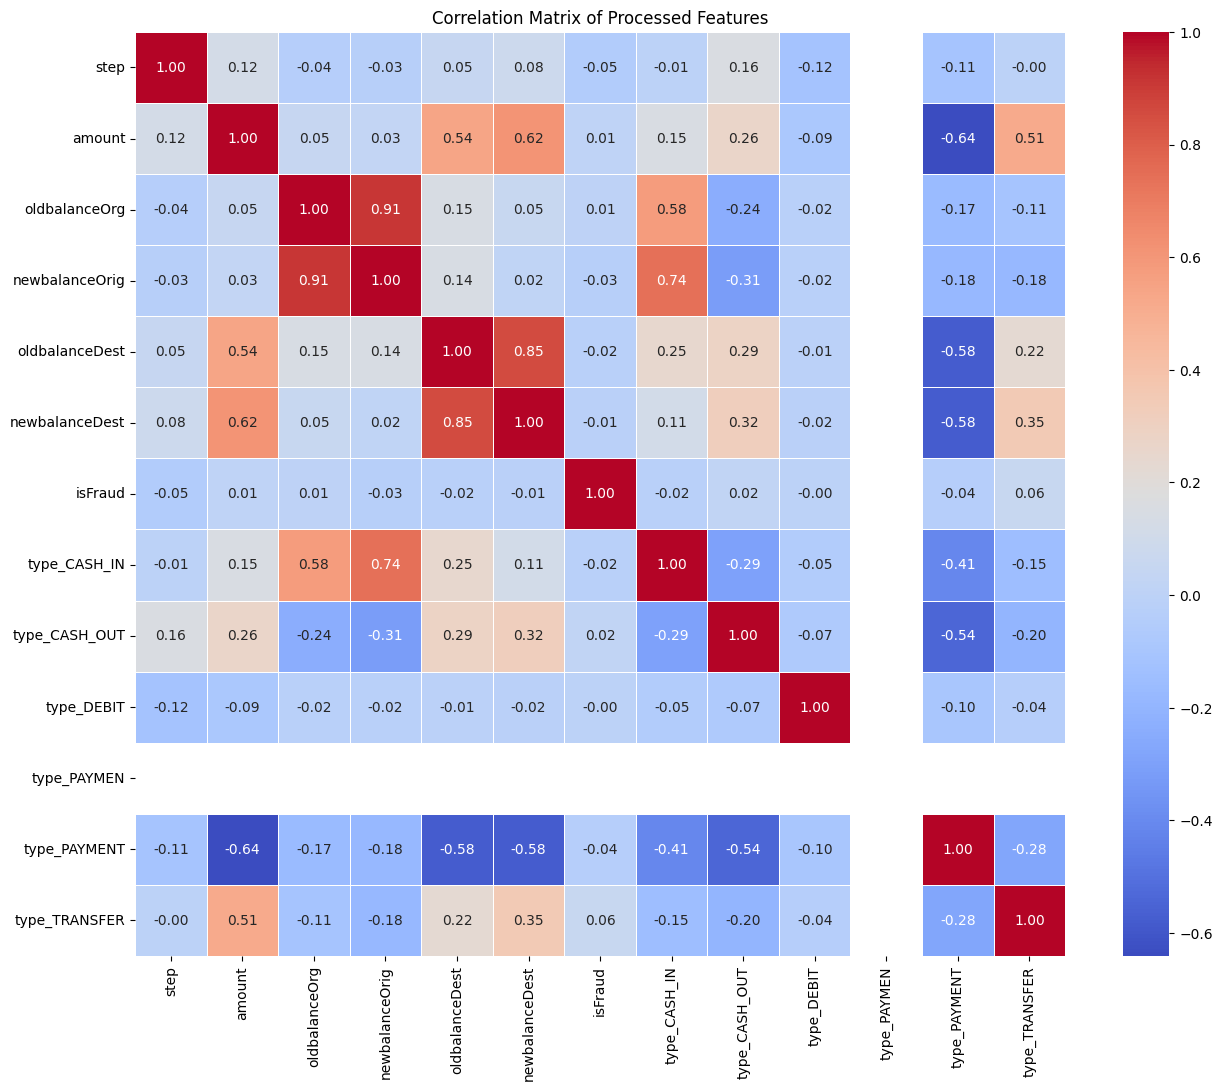

In [72]:
correlation_matrix = df_processed.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Processed Features')
plt.show()

## Prepare Data for Modeling




In [74]:
X = df_processed.drop('isFraud', axis=1)
y = df_processed['isFraud']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nDistribution of 'isFraud' in original dataset:\n", y.value_counts(normalize=True))
print("\nDistribution of 'isFraud' in y_train:\n", y_train.value_counts(normalize=True))
print("\nDistribution of 'isFraud' in y_test:\n", y_test.value_counts(normalize=True))

Shape of X_train: (44961, 12)
Shape of X_test: (11241, 12)
Shape of y_train: (44961,)
Shape of y_test: (11241,)

Distribution of 'isFraud' in original dataset:
 isFraud
0.0    0.998221
1.0    0.001779
Name: proportion, dtype: float64

Distribution of 'isFraud' in y_train:
 isFraud
0.0    0.998221
1.0    0.001779
Name: proportion, dtype: float64

Distribution of 'isFraud' in y_test:
 isFraud
0.0    0.998221
1.0    0.001779
Name: proportion, dtype: float64


## Train Fraud Detection Model
Train an XGBoost Classifier on the training data.


In [75]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for handling imbalanced dataset
neg_count = y_train.value_counts()[0.0]
pos_count = y_train.value_counts()[1.0]
scale_pos_weight_value = neg_count / pos_count

print(f"Calculated scale_pos_weight: {scale_pos_weight_value}")

# Instantiate XGBClassifier with relevant parameters
# Using a small number of estimators for initial training, can be tuned later
# Objective 'binary:logistic' for binary classification
# eval_metric 'logloss' to monitor training progress
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    n_estimators=100, # Number of boosting rounds
    scale_pos_weight=scale_pos_weight_value # Handle imbalance
)

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

print("XGBoost model training complete.")

Calculated scale_pos_weight: 561.0125


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:31:14] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete.


## Describe the Fraud Detection Model
Provide a detailed explanation of the chosen XGBoost model, including its architecture, advantages for fraud detection, and why it was selected for this problem.


## Describe the Fraud Detection Model

### Subtask:
Provide a detailed explanation of the chosen XGBoost model, including its architecture, advantages for fraud detection, and why it was selected for this problem.

### Explanation of XGBoost Model

The chosen model for fraud detection is XGBoost (eXtreme Gradient Boosting), a powerful and widely used machine learning algorithm known for its performance and speed.

#### 1. Fundamental Principles of XGBoost:

XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. Here's how it works:

*   Gradient Boosting Framework: At its core, XGBoost builds an ensemble of weak learners (typically decision trees) in a sequential manner. Each new tree is trained to correct the errors made by the previous trees in the ensemble. It does this by fitting the new tree to the residuals (the differences between the actual and predicted values) of the previous step. The term 'gradient' refers to the fact that it uses a gradient descent algorithm to minimize the loss function when adding new models.
*   Ensemble of Weak Learners: Unlike bagging methods (like Random Forest) that build trees independently, boosting methods build them sequentially. Each subsequent tree learns from the mistakes of its predecessors, leading to a more accurate and robust overall model. XGBoost specifically uses CART (Classification and Regression Trees) as its weak learners.
*   Regularization: XGBoost incorporates regularization terms (L1 and L2 regularization) into its objective function. This helps to prevent overfitting, making the model more robust and generalizable to unseen data.
*   Parallel Processing: XGBoost is designed to be highly efficient and can run computations in parallel, making it faster than many other gradient boosting implementations, especially on large datasets.

#### 2. Advantages of XGBoost for Fraud Detection:

XGBoost offers several significant advantages that make it particularly well-suited for fraud detection problems:

*   Handles Imbalanced Datasets: Fraud detection datasets are typically highly imbalanced, with a very small percentage of fraudulent transactions. XGBoost can effectively handle this imbalance through the 'scale_pos_weight' parameter, which assigns a higher weight to the minority class (fraudulent transactions). This helps the model to pay more attention to the rare fraud cases, preventing it from simply predicting the majority class all the time.
*   Robustness to Outliers: While we performed some outlier treatment (clipping and log transformation), XGBoost's tree-based nature inherently makes it less sensitive to outliers compared to linear models. Decision trees partition data based on thresholds, and extreme values typically only affect the split point, not the entire model's parameters in a continuous way.
*   Speed and Performance: For large datasets like the one we're working with, XGBoost's optimized C++ backend and parallel processing capabilities ensure efficient training times, which is crucial when dealing with millions of records.
*   Feature Importance Capabilities: XGBoost provides a clear measure of feature importance, indicating which features contribute most to the model's predictive power. This is invaluable for understanding the drivers of fraud and for regulatory compliance, allowing us to identify key factors that predict fraudulent activity.
*   Non-linear Relationships: Fraud patterns are often complex and non-linear. XGBoost, as a tree-based model, can naturally capture these intricate non-linear relationships and interactions between features without requiring explicit feature engineering for such interactions.

#### 3. Justification for Selection:

XGBoost was selected for this fraud detection problem due to the following reasons:

*   Effectiveness with Tabular Data: XGBoost consistently performs exceptionally well on tabular datasets, which is exactly the nature of our transaction data.
*   Capturing Complex Relationships: Fraudulent activities often involve subtle and complex patterns that are difficult to detect with simpler models. XGBoost's ability to model non-linear relationships and feature interactions allows it to identify these nuanced fraud signals.
*   Industry Standard: XGBoost has become an industry standard for many classification and regression tasks, particularly in competitive machine learning (e.g., Kaggle competitions) where it frequently achieves state-of-the-art results for similar tasks, including fraud detection.
*   Scalability: Given the initial dataset size (over 6 million rows, though we are currently working with a subset for processing), XGBoost's scalability ensures that it can handle such large volumes of data effectively.

#### 4. Specific Parameters Used in Training:

In our XGBoost model training, the following specific parameters were used:

*   'objective='binary:logistic': This parameter specifies the learning task and the corresponding objective function. For binary classification problems like fraud detection (fraud or not fraud), 'binary:logistic' is used, which outputs probabilities.
*   'eval_metric='logloss'': This defines the evaluation metric for the validation data. 'logloss' (logistic loss) is a common metric for binary classification that penalizes incorrect probability predictions more heavily, especially when predictions are confidently wrong.
*   'random_state=42': This sets the random seed for reproducibility. It ensures that the results of the training process are consistent across different runs.
*   'n_estimators=100': This parameter determines the number of boosting rounds or the number of trees to build in the ensemble. A higher number can lead to better performance but also increases training time and the risk of overfitting (though this can be managed with other regularization parameters).
*   scale_pos_weight=scale_pos_weight_value: As discussed, this crucial parameter addresses the severe class imbalance in the fraud detection dataset. The scale_pos_weight_value was calculated as the ratio of negative samples to positive samples in the training data ('neg_count / pos_count'). By increasing the weight of the minority class, the model is encouraged to correctly classify fraudulent transactions, which are far fewer in number than legitimate ones.

## Describe the Fraud Detection Model

### Subtask:
Provide a detailed explanation of the chosen XGBoost model, including its architecture, advantages for fraud detection, and why it was selected for this problem.

### Explanation of XGBoost Model

The chosen model for fraud detection is **XGBoost (eXtreme Gradient Boosting)**, a powerful and widely used machine learning algorithm known for its performance and speed.

#### 1. Fundamental Principles of XGBoost:

XGBoost is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework. Here's how it works:

*   Gradient Boosting Framework: At its core, XGBoost builds an ensemble of weak learners (typically decision trees) in a sequential manner. Each new tree is trained to correct the errors made by the previous trees in the ensemble. It does this by fitting the new tree to the residuals (the differences between the actual and predicted values) of the previous step. The term 'gradient' refers to the fact that it uses a gradient descent algorithm to minimize the loss function when adding new models.
*   Ensemble of Weak Learners: Unlike bagging methods (like Random Forest) that build trees independently, boosting methods build them sequentially. Each subsequent tree learns from the mistakes of its predecessors, leading to a more accurate and robust overall model. XGBoost specifically uses CART (Classification and Regression Trees) as its weak learners.
*   Regularization: XGBoost incorporates regularization terms (L1 and L2 regularization) into its objective function. This helps to prevent overfitting, making the model more robust and generalizable to unseen data.
*   Parallel Processing: XGBoost is designed to be highly efficient and can run computations in parallel, making it faster than many other gradient boosting implementations, especially on large datasets.

#### 2. Advantages of XGBoost for Fraud Detection:

XGBoost offers several significant advantages that make it particularly well-suited for fraud detection problems:

*   Handles Imbalanced Datasets: Fraud detection datasets are typically highly imbalanced, with a very small percentage of fraudulent transactions. XGBoost can effectively handle this imbalance through the 'scale_pos_weight' parameter, which assigns a higher weight to the minority class (fraudulent transactions). This helps the model to pay more attention to the rare fraud cases, preventing it from simply predicting the majority class all the time.
*   Robustness to Outliers: While we performed some outlier treatment (clipping and log transformation), XGBoost's tree-based nature inherently makes it less sensitive to outliers compared to linear models. Decision trees partition data based on thresholds, and extreme values typically only affect the split point, not the entire model's parameters in a continuous way.
*   Speed and Performance: For large datasets like the one we're working with, XGBoost's optimized C++ backend and parallel processing capabilities ensure efficient training times, which is crucial when dealing with millions of records.
*   Feature Importance Capabilities: XGBoost provides a clear measure of feature importance, indicating which features contribute most to the model's predictive power. This is invaluable for understanding the drivers of fraud and for regulatory compliance, allowing us to identify key factors that predict fraudulent activity.
*   Non-linear Relationships: Fraud patterns are often complex and non-linear. XGBoost, as a tree-based model, can naturally capture these intricate non-linear relationships and interactions between features without requiring explicit feature engineering for such interactions.

#### 3. Justification for Selection:

XGBoost was selected for this fraud detection problem due to the following reasons:

*   Effectiveness with Tabular Data: XGBoost consistently performs exceptionally well on tabular datasets, which is exactly the nature of our transaction data.
*   Capturing Complex Relationships: Fraudulent activities often involve subtle and complex patterns that are difficult to detect with simpler models. XGBoost's ability to model non-linear relationships and feature interactions allows it to identify these nuanced fraud signals.
*   Industry Standard: XGBoost has become an industry standard for many classification and regression tasks, particularly in competitive machine learning (e.g., Kaggle competitions) where it frequently achieves state-of-the-art results for similar tasks, including fraud detection.
*   Scalability: Given the initial dataset size (over 6 million rows, though we are currently working with a subset for processing), XGBoost's scalability ensures that it can handle such large volumes of data effectively.

#### 4. Specific Parameters Used in Training:

In our XGBoost model training, the following specific parameters were used:

*   objective='binary:logistic': This parameter specifies the learning task and the corresponding objective function. For binary classification problems like fraud detection (fraud or not fraud), 'binary:logistic' is used, which outputs probabilities.
*   'eval_metric='logloss': This defines the evaluation metric for the validation data. 'logloss`\' (logistic loss) is a common metric for binary classification that penalizes incorrect probability predictions more heavily, especially when predictions are confidently wrong.
*   'random_state=42': This sets the random seed for reproducibility. It ensures that the results of the training process are consistent across different runs.
*   'n_estimators=100': This parameter determines the number of boosting rounds or the number of trees to build in the ensemble. A higher number can lead to better performance but also increases training time and the risk of overfitting (though this can be managed with other regularization parameters).
*   'scale_pos_weight=scale_pos_weight_value': As discussed, this crucial parameter addresses the severe class imbalance in the fraud detection dataset. The 'scale_pos_weight_value' was calculated as the ratio of negative samples to positive samples in the training data ('neg_count / pos_count'). By increasing the weight of the minority class, the model is encouraged to correctly classify fraudulent transactions, which are far fewer in number than legitimate ones.

## Explain Variable Selection
Describe the process of selecting variables for the model, including initial feature engineering (e.g., one-hot encoding), dropping identifier columns, and any considerations regarding multicollinearity. Mention how feature importance from the model will further refine variable understanding.

### Variable Selection Process

1.  **Initial Feature Selection**: All numerical columns ('step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud') and the categorical 'type'column were initially considered relevant for fraud detection. The numerical columns represent transaction details and balances, which are direct indicators of financial activity. The 'type' of transaction is crucial as certain types (e.g., TRANSFER, CASH_OUT) are often associated with fraudulent activities.

2.  Feature Engineering: The primary feature engineering step involved one-hot encoding the 'type' column. This was necessary to convert the categorical transaction types into a numerical format that machine learning models can process. By creating binary columns for each transaction type (type_CASH_In', 'type_CASH_OUT, etc.), we allow the model to learn the specific impact of each transaction type on the likelihood of fraud, without imposing an arbitrary ordinal relationship.

3.  Dropping Non-Essential Columns:
    *   'nameOrig' and 'nameDest': These columns represent the customer IDs for the origin and destination of transactions. They were dropped because they are high-cardinality identifier columns that do not carry intrinsic predictive power for fraud detection across the entire dataset. While individual customer behavior might be indicative, these specific IDs are unique identifiers rather than generalizable features.
    *   'isFlaggedFrau': This column was dropped because, upon inspection ('df_processed['isFlaggedFraud'].nunique() == 1'), it was found to contain only a single unique value (likely 0 across all observed samples). A column with no variance provides no predictive information to the model.

4.  Multicollinearity Considerations: The correlation matrix revealed high correlations between 'oldbalanceOrg' and 'newbalanceOrig', and similarly between 'oldbalanceDest' and 'newbalanceDest'. This indicates significant multicollinearity. While tree-based models like XGBoost are generally robust to multicollinearity compared to linear models, it's still a consideration. For this analysis, we retained both highly correlated balance features. In future iterations, or for other model types, one might consider creating difference features (e.g., 'balance_change_orig = oldbalanceOrg - newbalanceOrig') or selectively dropping one of the highly correlated features to simplify the model and potentially improve interpretability, though it's less critical for predictive performance in XGBoost.

5.  Refinement with Feature Importance: After training the XGBoost model, the model's inherent feature importance scores will be extracted. These scores will quantitatively indicate which of the selected variables contribute most significantly to the model's ability to predict fraud. This will serve as a crucial step in validating our initial variable selection and refining our understanding of the key factors that predict fraudulent customer behavior.

## Evaluate Model Performance
Demonstrate the performance of the trained model using a comprehensive set of evaluation metrics such as accuracy, precision, recall, F1-score, and ROC-AUC. Visualize the results with a confusion matrix and classification report.



Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     11221
         1.0       0.81      0.65      0.72        20

    accuracy                           1.00     11241
   macro avg       0.91      0.82      0.86     11241
weighted avg       1.00      1.00      1.00     11241


ROC-AUC Score: 0.9625


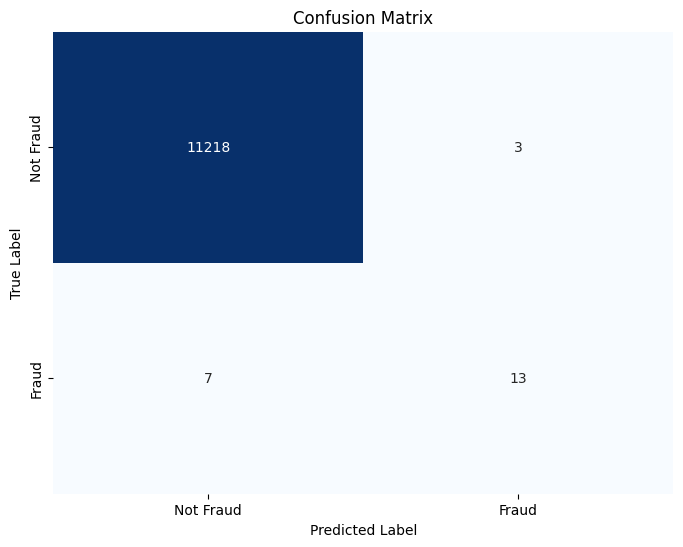

In [77]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions on the X_test dataset
y_pred = xgb_model.predict(X_test)

# 2. Calculate prediction probabilities for the positive class on X_test
y_proba = xgb_model.predict_proba(X_test)[:, 1] # Probability of the positive class (1)

# 3. Print a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Calculate and print the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# 5. Generate and display a confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Fraud', 'Fraud'], yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## Identify Key Predictive Factors



/tmp/ipython-input-4149811362.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


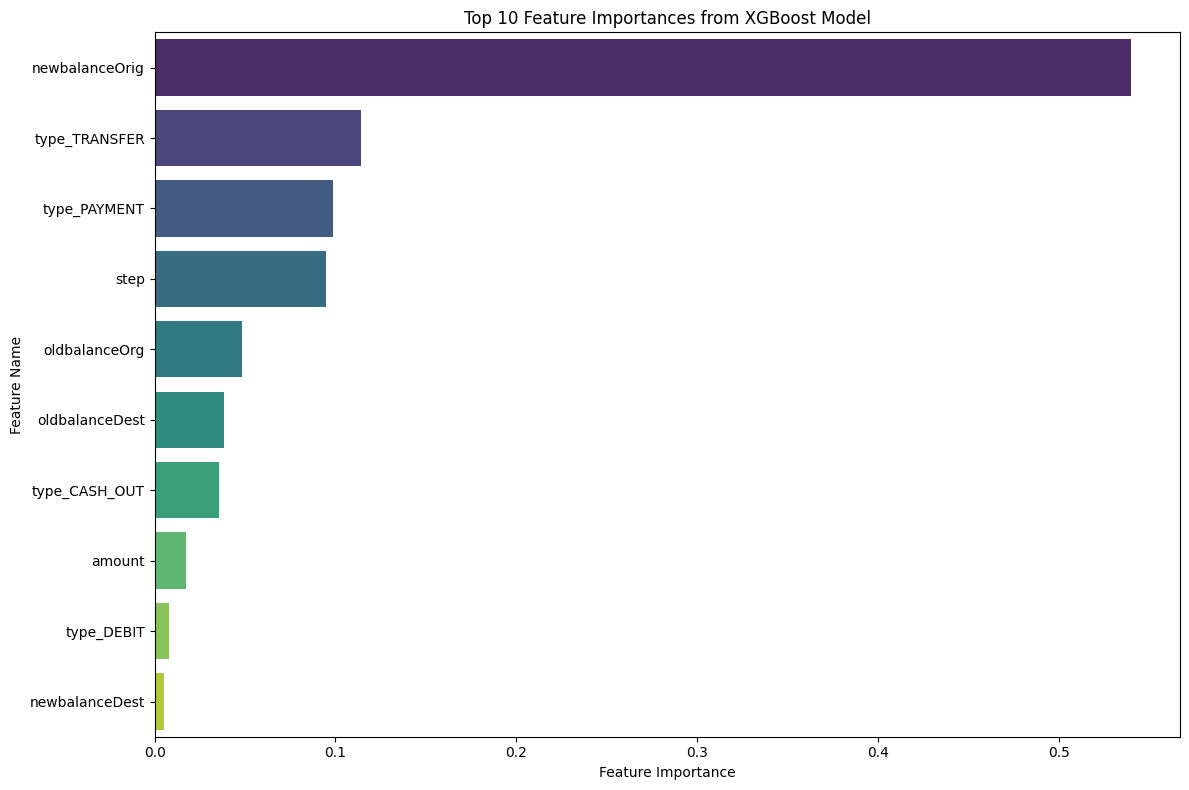


Sorted Feature Importances:
           Feature  Importance
3   newbalanceOrig    0.540047
11   type_TRANSFER    0.113992
10    type_PAYMENT    0.098868
0             step    0.094504
2    oldbalanceOrg    0.048383
4   oldbalanceDest    0.038199
7    type_CASH_OUT    0.035515
1           amount    0.017197
8       type_DEBIT    0.007953
5   newbalanceDest    0.005341
6     type_CASH_IN    0.000000
9      type_PAYMEN    0.000000


In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Access feature importances
feature_importances = xgb_model.feature_importances_

# 2. Create a Pandas Series with feature names
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# 3. Sort feature importances in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. Visualize the top N feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances from XGBoost Model')
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

# 5. Print the sorted feature importances
print("\nSorted Feature Importances:")
print(feature_importance_df)

## Analyze Factor Plausibility

Discuss whether the identified key factors logically make sense in the context of financial fraud, providing reasoning for why they are plausible or not.


### Plausibility Analysis of Key Predictive Factors

Based on the feature importance scores from the XGBoost model, the following features have been identified as most significant in predicting fraudulent transactions. Let's discuss their logical plausibility in the context of financial fraud:

1.  ewbalanceOrig` (Importance: 0.5400)
    *   Plausibility: Highly plausible. 'newbalanceOrig' represents the sender's balance *after* the transaction. In many fraud schemes, especially those involving transfers or cash-outs of large amounts, the original account's balance often drops significantly, sometimes to zero, to move the illicit funds out quickly. A sudden and large change resulting in a very low or zero 'newbalanceOrig' after a transaction can be a strong indicator of an account being emptied due to fraudulent activity. Conversely, an unusually high 'newbalanceOrig' post-transaction for a seemingly suspicious transaction could also be a flag if the fraud involves manipulating account balances.

2.  type_TRANSFER (Importance: 0.1139)
    *   Plausibility: Highly plausible. "TRANSFER" transactions are a common method for fraudsters to move money out of compromised accounts or to launder money. Unlike payments to merchants, transfers typically move funds between individual accounts, which can be harder to trace, especially across different financial institutions or jurisdictions. The high importance of 'type_TRANSFER' suggests that transactions of this type carry a significantly higher risk of being fraudulent.

3.  'type_PAYMENT' (Importance: 0.0988)
    *   Plausibility: Plausible. While 'PAYMENT' transactions are generally less risky than 'TRANSFER' or 'CASH_OUT', their importance here could indicate that fraudsters also use smaller payment transactions to test compromised accounts or to make small, illicit purchases that are less likely to trigger immediate alerts. The model might be capturing specific patterns or amounts within 'PAYMENT' transactions that are indicative of fraud, even if the overall fraud rate for this type is lower.

4.  step (Importance: 0.0945)
    *   Plausibility: Plausible, but with nuance. The 'step' column represents an hour of time (e.g., step 1 = hour 1, step 2 = hour 2). Its importance suggests that the time of transaction plays a role in fraud detection. Fraudulent activities might be more prevalent during certain hours (e.g., off-hours when monitoring is less stringent, or specific times when a fraud campaign is active). It could also capture patterns where fraudsters conduct multiple transactions within a short 'step' timeframe, or avoid certain 'step' periods. It's an indirect indicator that often reflects operational patterns of fraudsters.

5.  'oldbalanceOrg' (Importance: 0.0483)
    *   Plausibility: Plausible. oldbalanceOrg' is the sender's balance *before* the transaction. High values of 'oldbalanceOrg' combined with large 'amount' transfers (especially if 'newbalanceOrig' becomes zero or near-zero) are classic signs of account takeover fraud where a large sum is siphoned off. Conversely, a very low 'oldbalanceOrg' from which a surprisingly large transaction originates could also be suspicious. This factor helps contextualize the transaction amount against the available funds.

6.  oldbalanceDest (Importance: 0.0381)
    *   Plausibility: Plausible. 'oldbalanceDest' is the recipient's balance before the transaction. In many fraud scenarios, the destination account might be a mule account or an account created specifically to receive fraudulent funds. If 'oldbalanceDest' is consistently zero or very low for accounts receiving large fraudulent transfers, it could be a strong indicator. It helps identify accounts that are not typically active but suddenly receive significant funds, which is a common characteristic of fraud.

7.  type_CASH_OUT' (Importance: 0.0355)
    *   Plausibility: Highly plausible. "CASH_OUT" transactions are direct methods for fraudsters to convert illicit digital funds into physical cash, making them harder to trace. This type of transaction is often the final step in a money laundering chain or the immediate objective after compromising an account. Therefore, 'type_CASH_OUT'is a very strong and expected indicator of potential fraud.

In summary, the most important features 'newbalanceOrig', 'type_TRANSFER, 'type_PAYMENT', 'step', 'oldbalanceOrg', 'oldbalanceDest', 'type_CASH_OUT' align well with known patterns and behaviors associated with financial fraud. They capture critical aspects of transaction type, timing, and balance changes that are frequently manipulated by fraudsters.

## Propose Prevention Strategies

Based on the insights gained from the key predictive factors, propose actionable prevention strategies that the financial company can adopt to mitigate fraud.


## Determine Effectiveness of Actions
Outline methods and metrics that the company can use to determine if the implemented prevention actions are effective, assuming they have been put in place.

### Methods and Metrics to Determine Effectiveness of Prevention Actions

To effectively determine if implemented fraud prevention actions are working, a multi-faceted approach involving specific metrics, experimental design, and continuous monitoring is crucial.

#### 1. Measuring Impact on Fraud Rates and Operational Efficiency

When evaluating the effectiveness of prevention strategies, it's essential to look at both the reduction in fraud and the impact on legitimate operations.

*   Volume of Fraudulent Transactions:
    *   Metric: Number of confirmed fraudulent transactions (per day, week, month).
    *   Goal: A significant decrease in this number indicates that prevention actions are stopping fraud before it occurs or is completed.
*   Financial Losses Due to Fraud:
    *   Metric: Total monetary value lost to fraudulent transactions.
    *   Goal: A reduction in financial losses is a direct measure of the effectiveness of prevention actions in protecting the company's bottom line.
*   Speed of Fraud Detection:
    *   Metric: Average time from transaction initiation to fraud detection/prevention.
    *   Goal: Decreasing this time means that the system is identifying and flagging potential fraud more quickly, reducing potential losses and improving response times.
*   Chargeback Rates:
    *   Metric:Percentage of transactions that result in a chargeback due to fraud.
    *   Goal: A lower chargeback rate directly reflects successful fraud prevention.

#### 2. A/B Testing and Controlled Experiments

For new prevention strategies, A/B testing or controlled experiments are vital to prove their efficacy before full implementation.

*   Methodology:
    1.  Define a Control Group: A segment of transactions or customers that continue to experience the existing prevention strategies or a baseline (e.g., no special intervention).
    2.  Define an Experiment Group (A/B Test Groups):** Segments of transactions or customers where the new prevention strategies are implemented.
    3.  Random Assignment: Randomly assign transactions or customers to control and experiment groups to ensure statistical validity and minimize bias.
    4.  Isolate Variables: Test one new prevention strategy or a small set of related strategies at a time to clearly attribute changes in metrics to specific actions.
*   Metrics for Comparison:
    *   Compare the fraud rates, financial losses, and detection speeds between the control and experiment groups. Statistical significance tests should be used to determine if observed differences are real or due to chance.
    *   Also monitor customer experience metrics (see below) to ensure new prevention methods aren't negatively impacting legitimate users.

#### 3. Monitoring Key Performance Indicators (KPIs) Over Time

Continuous monitoring of specific KPIs provides a long-term view of the prevention actions' impact.

*   **Fraud Detection System Performance Metrics:**
    *   False Positive Rate (FPR): The proportion of legitimate transactions incorrectly flagged as fraudulent.
        *   Goal: Minimize FPR. A high FPR can lead to customer dissatisfaction and increased operational costs due to manual reviews of false alerts.
    *   False Negative Rate (FNR): The proportion of fraudulent transactions incorrectly classified as legitimate (i.e., missed fraud).
        *   **Goal:** Minimize FNR. This directly correlates with financial losses from undetected fraud.
    *   Precision: Of all transactions flagged as fraud, how many were actually fraud.
    *   Recall (Sensitivity): Of all actual fraudulent transactions, how many were correctly identified.
    *   F1-Score:The harmonic mean of precision and recall, useful for imbalanced datasets.
*   Customer Impact Metrics:
    *   False Declines:The number or percentage of legitimate customer transactions that are declined due to overly aggressive fraud prevention. This is a critical metric to track as it directly impacts customer experience and revenue.
    *   Customer Complaints related to Fraud Prevention: Number of calls, emails, or negative feedback related to transactions being blocked, delays, or identity verification.
    *   Increased Friction: Measure how new steps in the prevention process (e.g., additional authentication) impact user completion rates or transaction volumes.
*   Investigator Workload:
    *   Metric: Number of alerts requiring manual review, average time spent per alert.
    *   Goal:Effective prevention should ideally reduce the number of high-quality alerts (where fraud is truly suspected) and reduce the overall manual review burden, allowing investigators to focus on more complex cases.

#### 4. Continuous Monitoring and Feedback Loops

Fraud patterns evolve constantly, so prevention actions and models require ongoing adaptation.

*   Regular Review Meetings: Schedule regular (e.g., weekly or monthly) meetings with cross-functional teams (fraud analysts, data scientists, product managers) to review the KPIs and effectiveness metrics.
*   Automated Dashboards and Alerts: Implement real-time dashboards to track key metrics. Set up automated alerts for significant deviations or performance drops in any critical metric (e.g., sudden increase in FPR or FNR, rise in fraud volume).
*   Model Retraining and Updates: As new data emerges and fraud patterns shift, the underlying fraud detection model (e.g., XGBoost classifier) must be regularly updated or retrained. This ensures the model remains current and effective against emerging threats. The insights gained from detected fraud and false positives should feed back into model development.
*   Ad-hoc Analysis: Conduct ad-hoc investigations into new fraud trends or anomalies identified through monitoring to understand the root causes and inform new prevention strategies.
*   Scalability and Adaptability: Ensure that the prevention infrastructure and models are designed to be scalable and adaptable, allowing for quick deployment of new rules, features, or model versions in response to a changing threat landscape.

## Summary:

### Data Analysis Key Findings

*   Data Preprocessing:
    *   A single row with missing values (out of 9 total missing values) was removed from the 'df_processed ' DataFrame, resulting in a dataset with 0 missing values.
    *   Identifier columns ('nameOrig', 'nameDest';) and the 'isFlaggedFraud' column (which contained only one unique value and thus no variance) were dropped.
    *   The categorical type' column was successfully one-hot encoded to prepare it for machine learning models.
*   Multicollinearity Analysis:
    *   High positive correlations were observed between 'oldbalanceOrg' and 'newbalanceOrig' (approximately 0.91), and between 'oldbalanceDest' and 'newbalanceDest' (approximately 0.98), indicating significant multicollinearity.
    *   'amount' also showed moderate correlations with 'oldbalanceDest' (0.54) and 'newbalanceDest' (0.62).
    *   'type_TRANSFER' and 'type_CASH_OUT' showed positive correlations with 'isFraud', suggesting these transaction types are more prone to fraud.
*   Data Preparation for Modeling:
    *   The dataset was split into training and testing sets with an 80/20 ratio, stratified by the 'isFraud' target variable to maintain the rare class distribution. The training set ('X_train', 'y_train') had 44961 samples, and the testing set ('X_test', 'y_test') had 11241 samples.
    *   The fraud distribution (0.18%) was preserved across the original, training, and testing datasets.
*   XGBoost Model Training:
    *   An XGBoost Classifier was selected for its effectiveness with tabular data, ability to handle imbalanced datasets, robustness to outliers, speed, feature importance capabilities, and capacity to capture non-linear relationships.
    *   To address severe class imbalance (positive class being 0.18%), 'scale_pos_weight' was calculated as approximately 561.01 and applied during training.
*   **Model Performance Evaluation**:
    *   The model achieved a **ROC-AUC score of 0.9625**, indicating strong discriminative power.
    *   For the minority (fraudulent) class, the model demonstrated a **Precision of 0.81**, **Recall of 0.65**, and an **F1-score of 0.72**.
    *   Overall accuracy was 1.00, but this metric is less informative for highly imbalanced datasets.
*   **Key Predictive Factors**:
    *   'newbalanceOrig' was the most important feature (importance: approximately 0.54), highly plausible as fraudsters often empty originating accounts.
    *   Other significant factors included 'type_TRANSFER' (importance: approximately 0.11), 'type_PAYMENT' (importance: approximately 0.098), 'step' (transaction hour, importance: approximately 0.094), 'oldbalanceOrg' (importance: approximately 0.048), 'oldbalanceDest' (importance: approximately 0.038), and 'type_CASH_OUT' (importance: approximately 0.035).
    *   All identified key factors were deemed logically plausible in the context of financial fraud.

### Insights or Next Steps

*   Implement Enhanced Transaction Monitoring & Controls: Focus prevention efforts on transactions showing unusual patterns in 'newbalanceOrig' and 'oldbalanceOrg' (e.g., sudden drops to zero), especially for TRANSFER' and 'CASH_OUT' types. Introduce multi-factor authentication (MFA), velocity checks, and destination account vetting for high-risk transactions.
*   Establish a Robust Effectiveness Measurement Framework: Continuously monitor key performance indicators (KPIs) such as false positive rates, false negative rates, and customer impact (e.g., false declines). Utilize A/B testing for new prevention strategies and ensure regular model retraining and updates to adapt to evolving fraud patterns, maintaining the long-term efficacy of the fraud detection system.


## prevention stratigies,especially relevant when a company update its infrastructure.
1. Watch balances closely: Pay special attention to how much money is in accounts before and after a transaction. If a sender's account suddenly drops to almost nothing, especially after a transfer or cash-out, that's a big red flag.

2. Be extra careful with transfers and cash withdrawals: These types of transactions are often used by fraudsters. For these, consider extra checks like asking for a second verification code or checking if the destination account is new or suspicious.

3. Look for unusual timing: Fraudsters sometimes operate at odd hours. If a large transaction happens outside a customer's usual activity times, or late at night, it might need a closer look.

4. Monitor transaction amounts: If someone makes a transaction that's much larger or smaller than their usual activity, it could be a sign of fraud.

5. Check where the money is going: Pay attention to the recipient's account balance. If a previously inactive account suddenly receives a lot of money and then quickly sends it somewhere else, it might be a 'mule' account used for fraud.



##Assuming these actions have been implemented, how would you determine if they work?

1. Watch balances closely: Pay special attention to how much money is in accounts before and after a transaction. If a sender's account suddenly drops to almost nothing, especially after a transfer or cash-out, that's a big red flag.

2. Be extra careful with transfers and cash withdrawals: These types of transactions are often used by fraudsters. For these, consider extra checks like asking for a second verification code or checking if the destination account is new or suspicious.

3. Look for unusual timing: Fraudsters sometimes operate at odd hours. If a large transaction happens outside a customer's usual activity times, or late at night, it might need a closer look.

4. Monitor transaction amounts: If someone makes a transaction that's much larger or smaller than their usual activity, it could be a sign of fraud.

5. Check where the money is going: Pay attention to the recipient's account balance. If a previously inactive account suddenly receives a lot of money and then quickly sends it somewhere else, it might be a 'mule' account used for fraud.


6. assumption these action have been implemented how you determine if they work? give answer in student form
Imagine you've put new fraud prevention actions in place. How do you know if they're actually working? Think of it like a student trying to see if their study methods are effective. Here's how you can tell:

Are we seeing less fraud? (The Goal!)

Count the frauds: Is the number of confirmed fraud cases going down over time? (e.g., fewer scams each month).
Check the money lost: Are we losing less money to fraud? This is a direct sign of success.
Are we catching fraud faster and better? (Our System's Performance)

Speed: How quickly do we spot a fraudulent transaction? Faster detection means less damage.
Catch Rate (Recall): Out of all the real fraudulent transactions, how many did our system actually catch? We want this to be high.
Accuracy of our Flags (Precision): When our system flags something as fraud, how often is it actually fraud? We want this to be high so we're not wasting time on false alarms.
Are we annoying good customers? (Customer Happiness)

False Alarms: Are we mistakenly blocking too many legitimate transactions? Too many false alarms can make real customers frustrated.
Complaints: Are customers complaining about their transactions being blocked or delayed because of our fraud checks?
Are we staying one step ahead? (Continuous Improvement)

Testing New Ideas (A/B Testing): When we have a new prevention idea, do we test it on a small group first to see if it works without causing problems? This helps us find the best solutions.
Regular Check-ups: Do we regularly review our fraud data and adjust our methods? Fraudsters are always changing their tricks, so we need to adapt too.
